In [32]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import csv
import io

In [7]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"

df = pd.read_csv(DATA_RAW / "diabetic_data.csv")
df.shape

(101766, 50)

In [9]:
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [12]:
# Build the binary target
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print(df['readmitted'].value_counts())
print()
print(df['readmitted_30'].value_counts(normalize=True))


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted_30
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [14]:
# Missingness check
# This dataset encodes missing values as the string '?', not as NaN, pandas
# won't flag this as null by default, so df.isnull().sum() would be wrong
missing_pct = (df == '?').sum().sort_values(ascending=False) / len(df)*100
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)

weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


In [17]:
# Check for repeated patients
# Same patient can show up multiple times (repeated hospitalization)
# This matters for how the train/test split is done later, splitting
# by row instead of by patient would let the same patient appear
# in both sets, which leaks information and makes the model have
# better results that it should
print("Total encounters:", df['encounter_id'].nunique())
print("Unique patients:", df['patient_nbr'].nunique())
print(df['patient_nbr'].value_counts().head(10))

Total encounters: 101766
Unique patients: 71518
patient_nbr
88785891    40
43140906    28
1660293     23
23199021    23
88227540    23
23643405    22
84428613    22
92709351    21
90609804    20
89472402    20
Name: count, dtype: int64


## A1C result and readmission risk

A1C (HbA1c) measures average blood glucose over the past 2–3 months, making it
the standard marker of how well-controlled a patient's diabetes is. This dataset
doesn't record it as a number — it's the category `A1Cresult`, with `None`
meaning no A1C test was ordered during this specific hospital stay (a clinical
decision, not a missing measurement). Before looking at readmission rates,
it's worth checking how often A1C is even tested during an inpatient
admission, since that itself is informative.

In [18]:
# How often is A1C tested at all, nd what does the distribution look like?
print(df['A1Cresult'].value_counts())
print()
print(df['A1Cresult'].value_counts(normalize=True)*100)

A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64

A1Cresult
>8      48.278294
Norm    29.321894
>7      22.399812
Name: proportion, dtype: float64


In [20]:
# dropna=False keeps missing values in the count instead of silently discarding them
print(df['A1Cresult'].isna().sum())
print()
print(df['A1Cresult'].value_counts(dropna=False))
print()
print(df['A1Cresult'].value_counts(dropna=False, normalize=True)*100)

84748

A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

A1Cresult
NaN     83.277322
>8       8.073423
Norm     4.903406
>7       3.745848
Name: proportion, dtype: float64


In [22]:
# Recode missing A1C as an explicit, readable category
df['A1Cresult_filled'] = df['A1Cresult'].fillna('Not Tested')

readmit_by_a1c = df.groupby('A1Cresult_filled')['readmitted_30'].mean()*100
print(readmit_by_a1c.sort_values(ascending=False))

A1Cresult_filled
Not Tested    11.423278
>7            10.047219
>8             9.870983
Norm           9.659319
Name: readmitted_30, dtype: float64


**Finding:** Contrary to the initial hypothesis, readmission rate does not increase
monotonically with A1C severity (`Not Tested`: 11.4%, `>7`: 10.0%, `>8`: 9.9%,
`Norm`: 9.7%). The spread is small (~1.75 points on an 11% base rate), so A1C
category alone is a weak signal in isolation. The more notable result is that
untested patients have the *highest* rate, suggesting whether A1C was ordered
at all may reflect care thoroughness or how central diabetes was to that
admission, rather than glycemic severity itself being strongly predictive here.

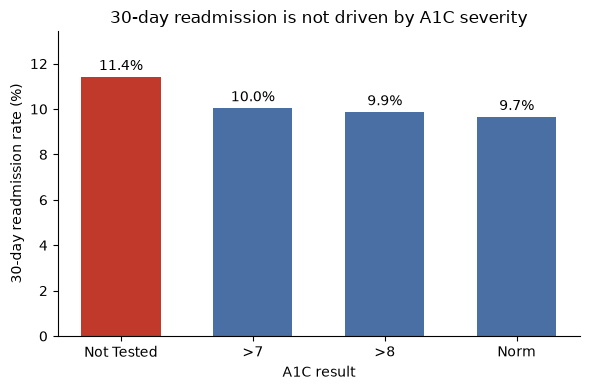

In [25]:
order = readmit_by_a1c.sort_values(ascending=False)
colors = ['#c0392b' if cat == 'Not Tested' else '#4a6fa5' for cat in order.index]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(order.index, order.values, color=colors, width=0.6)

for bar, value in zip(bars, order.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('30-day readmission rate (%)')
ax.set_xlabel('A1C result')
ax.set_title('30-day readmission is not driven by A1C severity')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(order.values) + 2)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'readmission_by_a1c.png', dpi=150)
plt.show()

## Prior inpatient visits and readmission risk

`number_inpatient` counts how many times this patient was hospitalized as an
inpatient in the year before this encounter. Hypothesis: more prior admissions
signals a more severe or medically complex patient, so readmission risk should
increase with it, though whether that relationship is linear, accelerating, or
flattens out is worth checking rather than assuming.

Before grouping this into buckets for a readmission-rate comparison, it's worth
looking at the raw distribution first, it's likely heavily concentrated at 0,
which would break a naive equal-sized quantile split.

In [26]:
# Check the raw distribution before deciding how to bucket it
print(df['number_inpatient'].value_counts().sort_index())
print()
print(df['number_inpatient'].describe())

number_inpatient
0     67630
1     19521
2      7566
3      3411
4      1622
5       812
6       480
7       268
8       151
9       111
10       61
11       49
12       34
13       20
14       10
15        9
16        6
17        1
18        1
19        2
21        1
Name: count, dtype: int64

count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64


In [28]:
# Bucket by where the data actually has volume, individual count for 0-2
# then a single 3+ group since higher counts too few patients to trust individually
def bucket_inpatient(n):
    if n >= 3:
        return '3+'
    return str(n)

df['number_inpatient_bucket'] = df['number_inpatient'].apply(bucket_inpatient)

order= ['0', '1', '2', '3+']
readmit_by_inpatient = df.groupby('number_inpatient_bucket')['readmitted_30'].mean().reindex(order)*100
print(readmit_by_inpatient)

number_inpatient_bucket
0      8.437084
1     12.924543
2     17.433254
3+    25.663215
Name: readmitted_30, dtype: float64


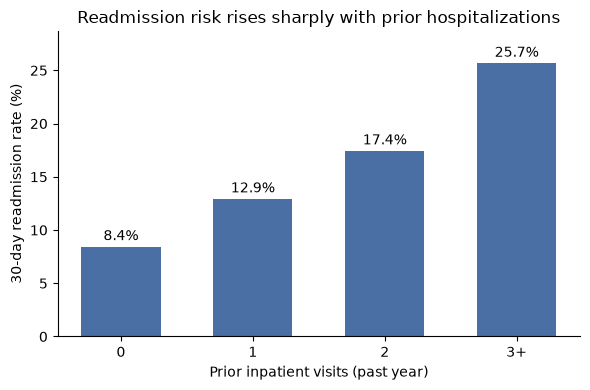

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(readmit_by_inpatient.index, readmit_by_inpatient.values, color='#4a6fa5', width=0.6)

for bar, value in zip(bars, readmit_by_inpatient.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('30-day readmission rate (%)')
ax.set_xlabel('Prior inpatient visits (past year)')
ax.set_title('Readmission risk rises sharply with prior hospitalizations')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(readmit_by_inpatient.values) + 3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'readmission_by_prior_inpatient.png', dpi=150)
plt.show()

**Finding:** Readmission risk rises sharply and steadily with prior inpatient
visits, 8.4% with none, 12.9% with one, 17.4% with two, and 25.7% with three
or more (a ~3x range, the strongest single-variable relationship found so far).
The step sizes trend upward rather than flattening out, consistent with a
"frequent flyer" pattern where medical complexity compounds with repeated
hospitalizations, rather than patients managing their condition better with
more hospital exposure. Caveat: the `3+` group blends everyone from 3 to 21
prior visits into one bucket, so that final step isn't a clean like-for-like
increment the way the first two are, a patient with 3 prior visits and one
with 21 are counted together.

## Discharge disposition and readmission risk

`discharge_disposition_id` records where the patient went after leaving the
hospital (home, a skilled nursing facility, hospice, etc.), one of the most
directly relevant variables to readmission risk, since it reflects how much
ongoing medical support the care team judged the patient to need after
discharge.

Before decoding anything: some discharge disposition codes mean the patient
died during this hospitalization, and others mean they were discharged to
hospice care. Readmission isn't a coherent concept for either group, a
patient who died can't meaningfully be "not readmitted," and a hospice patient
being readmitted would reflect a failure of the hospice referral, not of
discharge planning. These encounters need to be excluded from the analysis
entirely once the codes are decoded, not just labeled carefully.

The codes themselves are stored numerically in the main dataset and decoded
by a separate file, `IDS_mapping.csv` — which isn't a single clean table, it
stacks three separate lookup tables (admission type, discharge disposition,
admission source) in one file, so it needs inspecting before it can be parsed.

In [30]:
# Peek at the raw file structure before parsing, IDS_mapping.csv stacks three
# separate lookup tables in one file rather than a single clean table
IDS_MAPPING_PATH = PROJECT_ROOT / 'data' / 'raw' / 'IDS_mapping.csv'
with open(IDS_MAPPING_PATH) as f:
    for i, line in enumerate(f):
        print(i, repr(line))
        if i > 40:
            break

0 'admission_type_id,description\n'
1 '1,Emergency\n'
2 '2,Urgent\n'
3 '3,Elective\n'
4 '4,Newborn\n'
5 '5,Not Available\n'
6 '6,NULL\n'
7 '7,Trauma Center\n'
8 '8,Not Mapped\n'
9 ',\n'
10 'discharge_disposition_id,description\n'
11 '1,Discharged to home\n'
12 '2,Discharged/transferred to another short term hospital\n'
13 '3,Discharged/transferred to SNF\n'
14 '4,Discharged/transferred to ICF\n'
15 '5,Discharged/transferred to another type of inpatient care institution\n'
16 '6,Discharged/transferred to home with home health service\n'
17 '7,Left AMA\n'
18 '8,Discharged/transferred to home under care of Home IV provider\n'
19 '9,Admitted as an inpatient to this hospital\n'
20 '10,Neonate discharged to another hospital for neonatal aftercare\n'
21 '11,Expired\n'
22 '12,Still patient or expected to return for outpatient services\n'
23 '13,Hospice / home\n'
24 '14,Hospice / medical facility\n'
25 '15,Discharged/transferred within this institution to Medicare approved swing bed\n'
26 '16,D

In [31]:
# Split the file into its three stacked tables using the blank ',' separator lines
with open(IDS_MAPPING_PATH) as f:
    lines = f.read().splitlines()

blocks = []
current = []
for line in lines:
    if line.strip() == ',':
        if current:
            blocks.append(current)
        current = []
    else:
        current.append(line)
if current:
    blocks.append(current)

print(f"Found {len(blocks)} tables")
for b in blocks:
    print(b[0])

Found 3 tables
admission_type_id,description
discharge_disposition_id,description
admission_source_id,description


In [33]:
def parse_mapping_block(lines):
    reader = csv.reader(io.StringIO('\n'.join(lines)))
    next(reader)  # skip the header row
    mapping = {}
    for row in reader:
        if len(row) < 2:
            continue
        code, label = row[0], row[1]
        mapping[int(code)] = label
    return mapping

discharge_map = parse_mapping_block(blocks[1])  # blocks[1] = discharge_disposition table
for code, label in discharge_map.items():
    print(code, '-', label)

1 - Discharged to home
2 - Discharged/transferred to another short term hospital
3 - Discharged/transferred to SNF
4 - Discharged/transferred to ICF
5 - Discharged/transferred to another type of inpatient care institution
6 - Discharged/transferred to home with home health service
7 - Left AMA
8 - Discharged/transferred to home under care of Home IV provider
9 - Admitted as an inpatient to this hospital
10 - Neonate discharged to another hospital for neonatal aftercare
11 - Expired
12 - Still patient or expected to return for outpatient services
13 - Hospice / home
14 - Hospice / medical facility
15 - Discharged/transferred within this institution to Medicare approved swing bed
16 - Discharged/transferred/referred another institution for outpatient services
17 - Discharged/transferred/referred to this institution for outpatient services
18 - NULL
19 - Expired at home. Medicaid only, hospice.
20 - Expired in a medical facility. Medicaid only, hospice.
21 - Expired, place unknown. Medica

In [34]:
# Decode the column and apply the exclusion we metioned before
df['discharge_disposition_label'] = df['discharge_disposition_id'].map(discharge_map)

exclude_codes = [11, 13, 14, 19, 20, 21]  # expired or hospice — see reasoning above
excluded_mask = df['discharge_disposition_id'].isin(exclude_codes)
print(f"Excluding {excluded_mask.sum()} encounters ({excluded_mask.mean() * 100:.2f}%) as expired/hospice")

df_clinical = df[~excluded_mask].copy()
print(df_clinical.shape)

Excluding 2423 encounters (2.38%) as expired/hospice
(99343, 54)


In [35]:
# Volume distribution check
print(df_clinical['discharge_disposition_label'].value_counts())

discharge_disposition_label
Discharged to home                                                                                           60234
Discharged/transferred to SNF                                                                                13954
Discharged/transferred to home with home health service                                                      12902
NULL                                                                                                          3691
Discharged/transferred to another short term hospital                                                         2128
Discharged/transferred to another rehab fac including rehab units of a hospital .                             1993
Discharged/transferred to another type of inpatient care institution                                          1184
Not Mapped                                                                                                     989
Discharged/transferred to ICF                       

## Discharge disposition and readmission risk

Where a patient goes after leaving the hospital is one of the clearest signals
of how much ongoing medical support their care team judged them to need,
directly tied to the discharge-planning quality that CMS's readmission penalty
is meant to capture.

`discharge_disposition_id` has ~24 remaining categories after excluding
expired/hospice encounters, but volume is extremely uneven: three categories
alone (home, SNF, home with health service) cover 87.7% of the data, while
several others have single-digit patient counts, too few to trust an
individual rate estimate. `NULL` and `Not Mapped` aren't real clinical
categories, just undefined codes, so they're merged into one `Unknown`
bucket. `Left AMA` (left against medical advice) is kept as its own category
despite modest volume, since it's a clinically distinct, plausibly high-risk
discharge type worth isolating rather than burying in "Other."

In [36]:
# Bucket by category volume: keep any discharge type with enough patients (>=500)
# to trust an individual rate estimate; merge undefined codes into "Unknown";
# collapse the remaining low-volume tail into "Other".
# value_counts computed once here, not inside the function, to avoid
# recomputing it on every single row via .apply()
disposition_counts = df_clinical['discharge_disposition_label'].value_counts()

def bucket_disposition(label):
    if label in ('NULL', 'Not Mapped'):
        return 'Unknown'
    if disposition_counts[label] >= 500:
        return label
    return 'Other'

df_clinical['discharge_bucket'] = df_clinical['discharge_disposition_label'].apply(bucket_disposition)

readmit_by_discharge = df_clinical.groupby('discharge_bucket')['readmitted_30'].mean().sort_values(ascending=False) * 100
print(readmit_by_discharge)

discharge_bucket
Discharged/transferred to another rehab fac including rehab units of a hospital .    27.696939
Discharged/transferred to another type of inpatient care institution                 20.861486
Other                                                                                17.108434
Discharged/transferred to another short term hospital                                16.071429
Discharged/transferred to SNF                                                        14.662462
Left AMA                                                                             14.446228
Discharged/transferred to ICF                                                        12.760736
Discharged/transferred to home with home health service                              12.695706
Unknown                                                                              11.773504
Discharged to home                                                                    9.300395
Name: readmitted_30, dtype: float

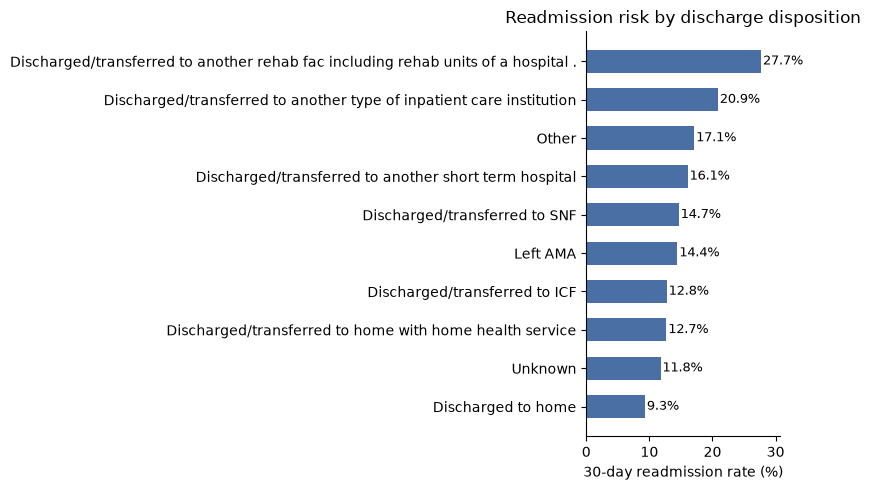

In [37]:
# Horizontal bar chart, these category labels are long, so horizontal bars
# read cleanly where rotated x-axis labels would overlap or get truncated
fig, ax = plt.subplots(figsize=(8, 5))
order = readmit_by_discharge.sort_values()  # ascending, so the largest lands at the top of the plot

bars = ax.barh(order.index, order.values, color='#4a6fa5', height=0.6)

for bar, value in zip(bars, order.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{value:.1f}%', va='center', fontsize=9)

ax.set_xlabel('30-day readmission rate (%)')
ax.set_title('Readmission risk by discharge disposition')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(order.values) + 3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'readmission_by_discharge.png', dpi=150)
plt.show()

**Finding:** 30-day readmission risk varies roughly 3x by discharge disposition,
from 9.3% for patients discharged home up to 27.7% for those transferred to
another rehab facility. Every institutional-transfer category sits well above
home discharge, consistent with these patients being judged too medically
complex for home care in the first place. Patients who left against medical
advice (14.45%) also show meaningfully elevated risk relative to a routine
discharge home, plausibly reflecting incomplete treatment. This is the
strongest, most clinically coherent signal found in the EDA so far.